Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Dataset path: /kaggle/input/brain-mri-images-for-brain-tumor-detection
Classes: ['no', 'yes']
Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.6897 - loss: 0.7383 - val_accuracy: 0.7400 - val_loss: 0.5323
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step - accuracy: 0.7882 - loss: 0.4835 - val_accuracy: 0.7400 - val_loss: 0.6166
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.8079 - loss: 0.4804 - val_accuracy: 0.7200 - val_loss: 0.5714
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.8522 - loss: 0.4271 - val_accuracy: 0.7400 - val_loss: 0.5249
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.8621 - loss: 0.3562 - val_accuracy: 0.7400 - val_loss: 0.5471
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.8818 - loss: 0.3018 - val_accuracy: 0.7800 - val_loss: 0.5395
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.9310 - loss: 0.1982 - val_accuracy: 0.8400 - val_loss: 0.4589
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 4s/step - accuracy: 0.9310 - loss: 0.1239 - val_accuracy: 0.8800 - val_loss: 0.4303
Epoch 9/

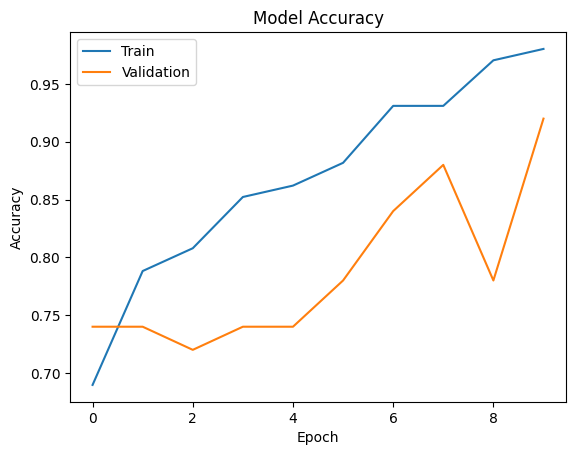

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Tumor probability: [[0.9980444]]


In [ ]:
# Install KaggleHub to download dataset automatically
!pip install kagglehub
# Import libraries
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Download dataset from Kaggle
path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")

print("Dataset path:", path)

# Locate dataset folder
dataset_dir = os.path.join(path, "brain_tumor_dataset")

print("Classes:", os.listdir(dataset_dir))

# 2. Data preprocessing
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

# 3. Build CNN model
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])
# 4. Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# 5. Train model
history = model.fit(
    train,
    epochs=10,
    validation_data=val
)
# 6. Plot training accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch"
)
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()
# 7. Test prediction on one MRI image
img = cv2.imread(os.path.join(dataset_dir,"yes","Y1.jpg"))
img = cv2.resize(img,(224,224))
img = img/255.0
img = np.expand_dims(img,axis=0)
prediction = model.predict(img)
print("Tumor probability:", prediction)